In [1]:
# ============================================================
# Mount Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# INSTALL LIBRARIES
# ============================================================
!pip install -q lightgbm==4.1.0 imbalanced-learn==0.12.3 h5py

import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import StandardScaler, label_binarize
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import ADASYN
from collections import Counter
import time
from imblearn.over_sampling import SMOTE

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 25.0 MB/s eta 0:00:00


In [3]:
# ============================================================
# Paths
# ============================================================
paths = {
    "train": "/content/drive/My Drive/Embedding_Concatenate_4Class/Train_4class.csv",
    "val":   "/content/drive/My Drive/Embedding_Concatenate_4Class/Val_4class.csv",
    "test":  "/content/drive/My Drive/Embedding_Concatenate_4Class/Test_4class.csv"
}

# ============================================================
# Load Data
# ============================================================
train_df = pd.read_csv(paths["train"])
val_df   = pd.read_csv(paths["val"])
test_df  = pd.read_csv(paths["test"])

In [4]:
# ============================================================
# EXTRACT X, y
# ============================================================
X_train = train_df.drop(columns=["Label"]).values.astype(np.float32)
y_train = train_df["Label"].values.astype(int)

X_val   = val_df.drop(columns=["Label"]).values.astype(np.float32)
y_val   = val_df["Label"].values.astype(int)

X_test  = test_df.drop(columns=["Label"]).values.astype(np.float32)
y_test  = test_df["Label"].values.astype(int)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Original training distribution:", Counter(y_train))

Original training distribution: Counter({np.int64(2): 333922, np.int64(1): 170147, np.int64(0): 77336, np.int64(3): 5127})


In [5]:
# ============================================================
# 1) UNDERSAMPLE MAJORITY CLASSES (1 = DDoS, 2 = Zero-Day)
# ============================================================
rus = RandomUnderSampler(
    sampling_strategy={
        1: 100000,   # DDoS
        2: 100000    # ZeroDay
    },
    random_state=42
)

X_rus, y_rus = rus.fit_resample(X_train_scaled, y_train)
print("After undersampling:", Counter(y_rus))

# ---------------------------------
# 2) SMOTE for Benign (class 0)
# ---------------------------------
smote = SMOTE(
    sampling_strategy={0: 100000},
    random_state=42,
    k_neighbors=5
)

X_sm, y_sm = smote.fit_resample(X_rus, y_rus)
print("After SMOTE (Benign):", Counter(y_sm))


# ============================================================
# 2) APPLY ADASYN ONLY TO MINORITY CLASS (3 = Malware)
# ============================================================
adasyn = ADASYN(
    sampling_strategy={3: 100000},  # Malware from 5k → 1 lac
    random_state=42,
    n_neighbors=3
)

X_train_bal, y_train_bal = adasyn.fit_resample(X_sm, y_sm)
print("After ADASYN minority class:", Counter(y_train_bal))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


After undersampling: Counter({np.int64(1): 100000, np.int64(2): 100000, np.int64(0): 77336, np.int64(3): 5127})


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


After SMOTE (Benign): Counter({np.int64(0): 100000, np.int64(1): 100000, np.int64(2): 100000, np.int64(3): 5127})


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


After ADASYN minority class: Counter({np.int64(3): 100362, np.int64(0): 100000, np.int64(1): 100000, np.int64(2): 100000})


In [6]:
params = {
    "objective": "multiclass",
    "num_class": 4,
    "learning_rate": 0.05,
    "num_leaves": 64,              # moderately small to allow splits
    "max_depth": 6,                # moderately small to reduce overfitting
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "metric": "multi_logloss",
    "device": "cpu",               # Changed from 'gpu' to 'cpu' to resolve persistent split error
    "min_data_in_leaf": 1,         # Already set to 1 to prevent empty leaf nodes
    "min_sum_hessian_in_leaf": 1e-2,
    "verbose": -1
}

In [7]:
start = time.time()

# Create LightGBM datasets
train_data = lgb.Dataset(X_train_bal, label=y_train_bal)
val_data   = lgb.Dataset(X_val_scaled, label=y_val, reference=train_data)

# Train the model
model = lgb.train(
    params,
    train_data,
    num_boost_round=100,  # Number of boosting rounds
    valid_sets=[train_data, val_data],
    callbacks=[
        lgb.early_stopping(10, verbose=False), # Stop if validation metric doesn't improve for 10 rounds
        lgb.log_evaluation(period=0) # Suppress verbose output of evaluation
    ]
)

end = time.time()
print(f"Training duration: {end - start:.2f} seconds")

Training duration: 60.28 seconds


In [8]:
# ============================================================
# SAVE MODEL
# ============================================================
model_dir = "/content/drive/My Drive/Ensemble model training/100k_ADASYN_LightGBM_4Class"
os.makedirs(model_dir, exist_ok=True)

model.save_model(f"{model_dir}/lightgbm_4class_model.json")
print("Model saved.")

Model saved.


In [9]:
# ============================================================
# Function to evaluate splits (with Confusion Matrix)
# ============================================================
def eval_split(name, X, y):
    preds = model.predict(X).argmax(axis=1)
    print(f"\n{name} REPORT:")
    print(classification_report(y, preds, digits=4))
    print(f"{name} Confusion Matrix:")
    print(confusion_matrix(y, preds))

# Evaluate all splits
eval_split("TRAIN", X_train_bal, y_train_bal)
eval_split("VAL", X_val_scaled, y_val)
eval_split("TEST", X_test_scaled, y_test)


TRAIN REPORT:
              precision    recall  f1-score   support

           0     0.9850    0.0026    0.0052    100000
           1     0.6297    1.0000    0.7728    100000
           2     0.7206    1.0000    0.8376    100000
           3     0.9790    1.0000    0.9894    100362

    accuracy                         0.7509    400362
   macro avg     0.8286    0.7506    0.6512    400362
weighted avg     0.8287    0.7509    0.6515    400362

TRAIN Confusion Matrix:
[[   263  58805  38774   2158]
 [     3  99996      1      0]
 [     1      0  99999      0]
 [     0      0      0 100362]]

VAL REPORT:
              precision    recall  f1-score   support

           0     0.1481    0.0006    0.0012     25748
           1     0.7892    0.9998    0.8821     56682
           2     0.9176    0.9997    0.9569    111309
           3     0.7355    0.9713    0.8371      1709

    accuracy                         0.8679    195448
   macro avg     0.6476    0.7429    0.6693    195448
weighted

In [10]:
# ============================================================
# Macro-F1 Score for Train, Validation, Test
# ============================================================
from sklearn.metrics import f1_score

def compute_macro_f1(name, X, y):
    preds = model.predict(X).argmax(axis=1)
    macro_f1 = f1_score(y, preds, average="macro")
    print(f"{name} Macro-F1 Score: {macro_f1:.4f}")

compute_macro_f1("TRAIN", X_train_bal, y_train_bal)
compute_macro_f1("VAL", X_val_scaled, y_val)
compute_macro_f1("TEST", X_test_scaled, y_test)

TRAIN Macro-F1 Score: 0.6512
VAL Macro-F1 Score: 0.6693
TEST Macro-F1 Score: 0.6883


In [11]:
# ============================================================
# ROC CURVES
# ============================================================
# Use scaled/balanced features
y_proba_test = model.predict(X_test_scaled)

# Ensure classes and n_classes are defined for ROC plotting
classes = np.array([0, 1, 2, 3])
n_classes = 4

# Ensure y_test_bin is available. If the kernel was restarted,
# it might need to be re-binarized.
if 'y_test_bin' not in locals() and 'y_test_bin' not in globals():
    # Assuming y_test is available from the previous cell's data preparation
    y_test_bin = label_binarize(y_test, classes=classes)

fpr = {}
tpr = {}
roc_auc = {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

print("\nPer-class AUC:")
for i in range(n_classes):
    print(f" Class {i}: AUC = {roc_auc[i]:.4f}")
print("Macro AUC:", roc_auc["macro"])


Per-class AUC:
 Class 0: AUC = 0.6269
 Class 1: AUC = 0.9451
 Class 2: AUC = 0.9402
 Class 3: AUC = 0.9962
Macro AUC: 0.8770815141421626


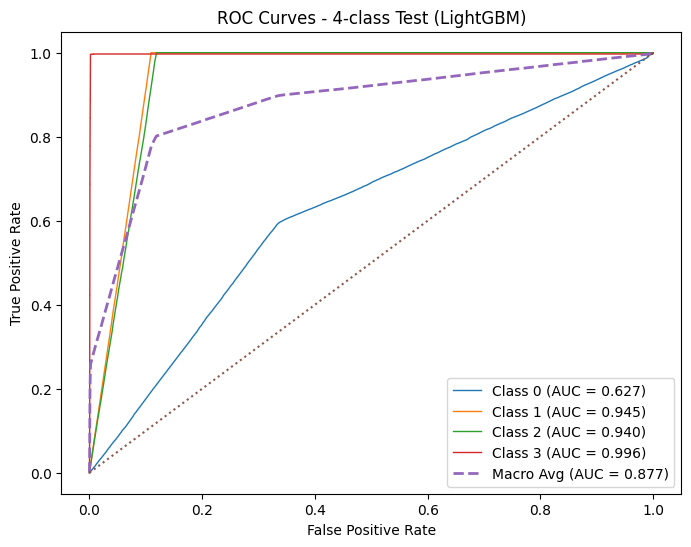


ROC saved to: /content/drive/My Drive/Ensemble model training/100k_ADASYN_LightGBM_4Class/roc_curve_test.png


In [12]:
# Save ROC plot
plt.figure(figsize=(8,6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], linewidth=1,
             label=f"Class {classes[i]} (AUC = {roc_auc[i]:.3f})")
plt.plot(fpr["macro"], tpr["macro"], linewidth=2, linestyle='--',
         label=f"Macro Avg (AUC = {roc_auc['macro']:.3f})")
plt.plot([0,1], [0,1], linestyle=':')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - 4-class Test (LightGBM)")
plt.legend()
roc_path = f"{model_dir}/roc_curve_test.png"
plt.savefig(roc_path)
plt.show()
print("\nROC saved to:", roc_path)

In [13]:
# ============================================================
# 8) CONFUSION MATRIX PLOTTING
# ============================================================

cm_save_path = model_dir
os.makedirs(cm_save_path, exist_ok=True)

def plot_cm_and_save(cm, title, filename):
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.colorbar()
    plt.tight_layout()

    save_file = f"{cm_save_path}/{filename}"
    plt.savefig(save_file)
    print(f"Saved: {save_file}")
    plt.show()

def generate_cm(name, X, y, filename):
    pred = model.predict(X)
    cm = confusion_matrix(y, pred)
    print(f"\n===== Confusion Matrix: {name} =====")
    print(cm)
    plot_cm_and_save(cm, f"Confusion Matrix: {name}", filename)

# IMPORTANT: update TRAIN to balanced data
generate_cm("Train (Balanced)", X_train_bal, y_train_bal, "cm_train.png")

# Validation on original data
generate_cm("Validation", X_val, y_val, "cm_val.png")

# Test on original data
generate_cm("Test", X_test, y_test, "cm_test.png")

ValueError: Classification metrics can't handle a mix of multiclass and continuous-multioutput targets


===== Confusion Matrix: Train (Balanced) =====
[[   263  58805  38774   2158]
 [     3  99996      1      0]
 [     1      0  99999      0]
 [     0      0      0 100362]]
Saved: /content/drive/My Drive/Ensemble model training/100k_ADASYN_LightGBM_4Class/cm_train.png


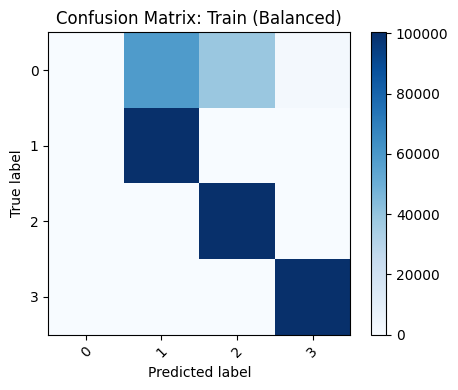


===== Confusion Matrix: Validation =====
[[    16  15141   9996    595]
 [    13  56669      0      0]
 [    30      0 111277      2]
 [    49      0      0   1660]]
Saved: /content/drive/My Drive/Ensemble model training/100k_ADASYN_LightGBM_4Class/cm_val.png


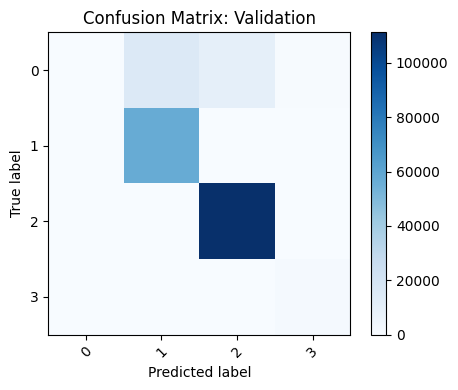


===== Confusion Matrix: Test =====
[[    29  15165   9990    335]
 [    21  56694      0      0]
 [    25      0 111299      0]
 [    35      0      1   1925]]
Saved: /content/drive/My Drive/Ensemble model training/100k_ADASYN_LightGBM_4Class/cm_test.png


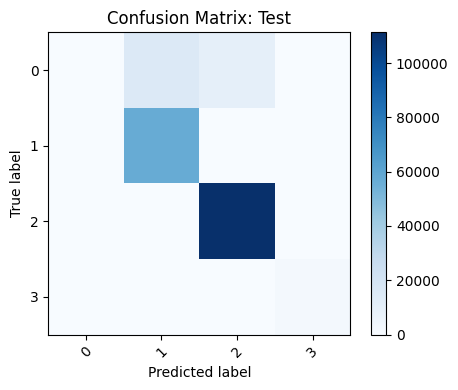

In [14]:
# ============================================================
# 8) CONFUSION MATRIX PLOTTING
# ============================================================

cm_save_path = model_dir
os.makedirs(cm_save_path, exist_ok=True)

def plot_cm_and_save(cm, title, filename, y_true):
    plt.figure(figsize=(5,4)) # Reverted figure size for plots without numbers
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.colorbar()
    tick_marks = np.arange(len(np.unique(y_true)))
    plt.xticks(tick_marks, np.unique(y_true), rotation=45)
    plt.yticks(tick_marks, np.unique(y_true))

    plt.tight_layout()

    save_file = f"{cm_save_path}/{filename}"
    plt.savefig(save_file)
    print(f"Saved: {save_file}")
    plt.show()

def generate_cm(name, X, y, filename):
    pred_proba = model.predict(X)
    pred = pred_proba.argmax(axis=1) # Convert probabilities to class labels
    cm = confusion_matrix(y, pred)
    print(f"\n===== Confusion Matrix: {name} =====")
    print(cm)
    plot_cm_and_save(cm, f"Confusion Matrix: {name}", filename, y) # Call plot_cm_and_save

# IMPORTANT: update TRAIN to balanced data
generate_cm("Train (Balanced)", X_train_bal, y_train_bal, "cm_train.png")

# Validation on original data
generate_cm("Validation", X_val_scaled, y_val, "cm_val.png") # Use scaled validation data

# Test on original data
generate_cm("Test", X_test_scaled, y_test, "cm_test.png") # Use scaled test data


===== Confusion Matrix: Train (Balanced) =====
[[   263  58805  38774   2158]
 [     3  99996      1      0]
 [     1      0  99999      0]
 [     0      0      0 100362]]
Saved: /content/drive/My Drive/Ensemble model training/100k_ADASYN_LightGBM_4Class/cm_train.png


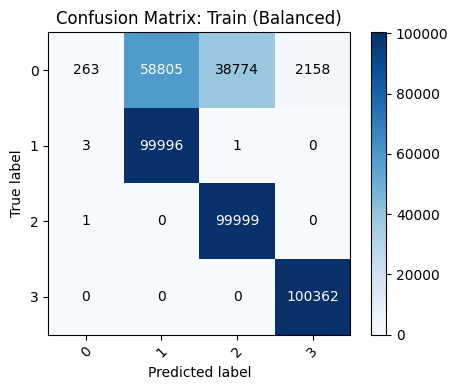


===== Confusion Matrix: Validation =====
[[    16  15141   9996    595]
 [    13  56669      0      0]
 [    30      0 111277      2]
 [    49      0      0   1660]]
Saved: /content/drive/My Drive/Ensemble model training/100k_ADASYN_LightGBM_4Class/cm_val.png


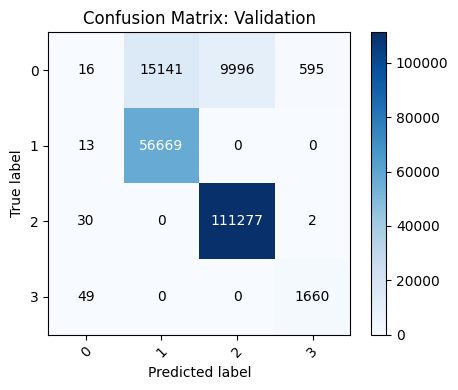


===== Confusion Matrix: Test =====
[[    29  15165   9990    335]
 [    21  56694      0      0]
 [    25      0 111299      0]
 [    35      0      1   1925]]
Saved: /content/drive/My Drive/Ensemble model training/100k_ADASYN_LightGBM_4Class/cm_test.png


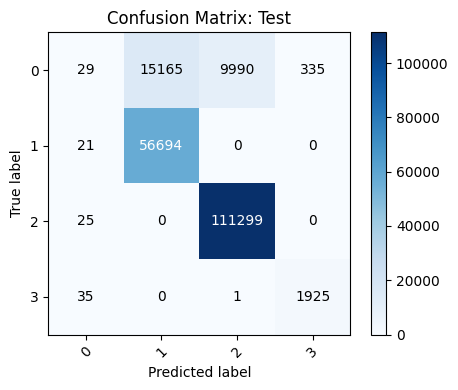

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import os

# ============================================================
# 8) CONFUSION MATRIX PLOTTING
# ============================================================

cm_save_path = model_dir
os.makedirs(cm_save_path, exist_ok=True)

def plot_cm_and_save(cm, title, filename, y_true):
    plt.figure(figsize=(5,4))  # Reverted figure size for plots without numbers
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.colorbar()
    tick_marks = np.arange(len(np.unique(y_true)))
    plt.xticks(tick_marks, np.unique(y_true), rotation=45)
    plt.yticks(tick_marks, np.unique(y_true))

    # Add text annotations within the matrix for clarity
    thresh = cm.max() / 2.  # Set threshold for text color
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()

    save_file = f"{cm_save_path}/{filename}"
    plt.savefig(save_file)
    print(f"Saved: {save_file}")
    plt.show()

def generate_cm(name, X, y, filename):
    pred_proba = model.predict(X)
    pred = pred_proba.argmax(axis=1)  # Convert probabilities to class labels
    cm = confusion_matrix(y, pred)
    print(f"\n===== Confusion Matrix: {name} =====")
    print(cm)
    plot_cm_and_save(cm, f"Confusion Matrix: {name}", filename, y)  # Call plot_cm_and_save

# IMPORTANT: update TRAIN to balanced data
generate_cm("Train (Balanced)", X_train_bal, y_train_bal, "cm_train.png")

# Validation on original data
generate_cm("Validation", X_val_scaled, y_val, "cm_val.png")  # Use scaled validation data

# Test on original data
generate_cm("Test", X_test_scaled, y_test, "cm_test.png")  # Use scaled test data